# Projeto 1

Modelo de entrega da questão 2.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 2: Resolvendo sistemas tridiagonais.

### Questão 2.1
Escreva, em Python ou Julia, uma função `solve_tridiag(A, b)` que recebe uma matriz quadrada $A$ e um vetor $b$ e retorna a solução do sistema $Ax = b$ (você pode supor que $A$ é inversível).

In [58]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

In [59]:
def solve_tridiag(A, b):
    
    A_nrow = A.shape[0]
    x = b.astype(float)
    
    diag_sup = np.diag(A, k=1).astype(float)
    diag = np.diag(A).astype(float)
    diag_inf = np.diag(A, k=-1).astype(float)
    
    for i in range(A_nrow-1):
        t = diag_inf[i] / diag[i]
        diag[i+1] = diag[i+1] - t*diag_sup[i]
        x[i+1] = x[i+1] - t*x[i]
        
    
    x[A_nrow-1] =  x[A_nrow-1]/diag[A_nrow-1]
    
    for i in reversed(range(A_nrow-1)):
        x[i] = (x[i] - x[i+1]*diag_sup[i])/diag[i]
        
    return x

### Questão 2.2
Verifique que sua função está correta, fazendo alguns testes.

In [60]:
A1 = np.array([
        [ 2.0, -1.0,  0.0],
        [-1.0,  2.0, -1.0],
        [ 0.0, -1.0,  2.0]
    ])
b1 = np.array([1.0, 0.0, 1.0])


print(solve_tridiag(A1.copy(),b1.copy()))
print(np.linalg.solve(A1.copy(), b1.copy()))



[1. 1. 1.]
[1. 1. 1.]


In [61]:
n2 = 5
A2 = np.diag(np.full(n2, 2.0)) + \
    np.diag(np.full(n2-1, -1.0), -1) + \
    np.diag(np.full(n2-1, -1.0), 1)
b2 = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

print(solve_tridiag(A2.copy(),b2.copy()))
print(np.linalg.solve(A2.copy(), b2.copy()))

[ 58.33333333 106.66666667 135.         133.33333333  91.66666667]
[ 58.33333333 106.66666667 135.         133.33333333  91.66666667]


In [62]:
A3 = np.array([
        [10.0,  1.0,  0.0,  0.0],
        [ 2.0, 12.0,  3.0,  0.0],
        [ 0.0,  4.0, 15.0,  5.0],
        [ 0.0,  0.0,  6.0, 20.0]
    ])
b3 = np.array([5.0, -2.0, 8.0, 1.0])

print(solve_tridiag(A3.copy(),b3.copy()))
print(np.linalg.solve(A3.copy(), b3.copy()))

[ 0.54327902 -0.43279022  0.70230821 -0.16069246]
[ 0.54327902 -0.43279022  0.70230821 -0.16069246]


### Questão 2.3
Qual é a complexidade computacional da sua função?

A função `solve_tridiag` possui dois loops não aninhados principais que iteram, dada uma matriz $n$ x $n$, $n$ vezes:

```python 
for i in range(A_nrow-1):
        t = A[i+1,i] / A[i,i]
        A[i+1] = A[i+1] - t*A[i]
        x[i+1] = x[i+1] - t*x[i]
        
for i in reversed(range(A_nrow-1)):
        x[i] = (x[i] - x[i+1]*A[i, i+1])/A[i,i]
``` 
Como sabemos que operações fora do loop não alteram a nossa complexidade, vamos nos concetrar naquelas que estão dentro. No primeiro for, temos 3 operações e no segundo, 1, que são executadas $n - 1$ vezes que totalizam $4n + 4$ operações $\rightarrow$ $O(n)$.

### Questão 2.4
A partir de que tamanho de matriz $A$ a função `solve_tridiag` se torna mais rápida do que a função `numpy.linalg.solve` (ou `\`, em Julia)?
Como você fez para chegar neste resultado?

### Resposta

A função `solve_tridiag` se torna mais rápida que a do numpy a partir de uma matriz no intervalo de 160x160 a 180x180. Professor, minha ideia inicial era calcular a matriz inversa e depois apenas resolver o sistema linear multiplicando $x = A^{-1}b$, mas depois de procurar alguns conteúdos e assistir algumas aulas aprendi que calcular a inversa de uma matriz não é nada divertido para matrizes grandes porque nós teríamos um problema de complexidade computacional muito grande. Portanto, voltei ao material para tentar entender como eu poderia resolver o problema de forma mais eficaz. Procurei entender melhor como funciona a função `numpy.linalg.solve` e descobri que nossa principal vantagem com relação a ela é que ela não sabe que a matriz do sistema linear que ela está resolvendo é tridiagonal e nós, sim. Então, podemos fazer certas operações que não funcionariam para qulquer matriz. 

Nós sabemos que os valores fora da diagonal principal, superior e inferior são zero. Então, não precisamos trabalhar com a matriz inteira, apenas com as três diagonais. Lógica da função:

1) Fazemos o escalonamento, mas não precisamos computar a subtração das entradas da diagonal inferior porque sabemos que será 0. Assim, calculamos os multiplicadores $t$ para fazer a alteração nos valores da diagonal principal e de b. Tendo concluído o escalonamento vamos ao segundo passo:

2) Backsubstituition. Agora, temos que o nosso $x_n = b_n / A_{n,n}$, e $x_i = (b_i - A_{i, i+1} * x_{i+1})/A_{i,i}$ para $i = 1, ..., n-1$

In [63]:
def benchmark(func, *args, num_times = 400):
    for i in range(10):
        func(*args)
    
    arr = np.zeros(num_times)
    
    for i in range(num_times):
        initial_time = time.perf_counter()
        func(*args)
        final_time = time.perf_counter()
        
        arr[i] = final_time - initial_time
        
    min = arr.min()
    
    return min

<Axes: title={'center': 'Desempenho'}, xlabel='size'>

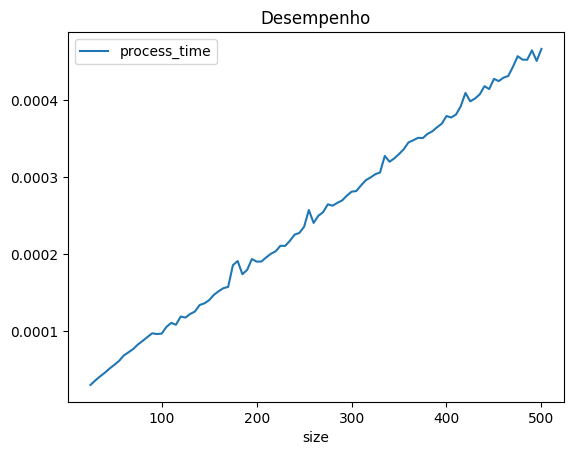

In [64]:
data_solve_tridiag = []         

for n in range(25, 501, 5):

    A_rand = np.diag(np.random.rand(n)) + np.diag(np.random.rand(n-1), -1) + np.diag(np.random.rand(n-1), 1)
    b_rand = np.random.rand(n)

    tempo_estavel = benchmark(solve_tridiag, A_rand, b_rand)

    data_solve_tridiag.append({"size": n, "process_time": tempo_estavel})

df_solve_tridiag = pd.DataFrame(data_solve_tridiag)
df_solve_tridiag.plot(x="size", y="process_time", title="Desempenho")




<Axes: title={'center': 'Desempenho'}, xlabel='size'>

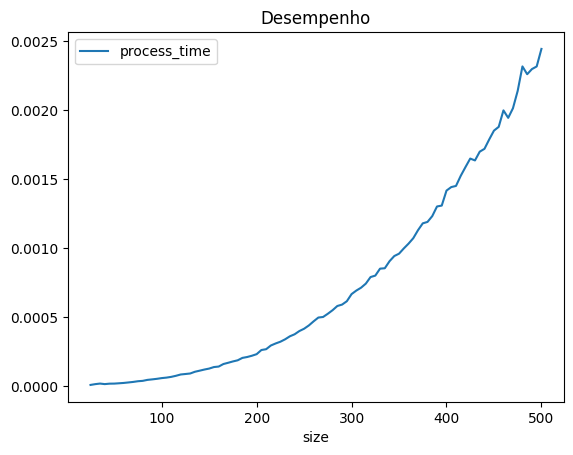

In [65]:
data_linalg_solve = []

for n in range(25, 501, 5):

    A_rand = np.diag(np.random.rand(n)) + np.diag(np.random.rand(n-1), -1) + np.diag(np.random.rand(n-1), 1)
    b_rand = np.random.rand(n)

    
    tempo_estavel = benchmark(np.linalg.solve, A_rand, b_rand)

    
    data_linalg_solve.append({"size": n, "process_time": tempo_estavel})

df_linalg_solve = pd.DataFrame(data_linalg_solve)
df_linalg_solve.plot(x="size", y="process_time", title="Desempenho")



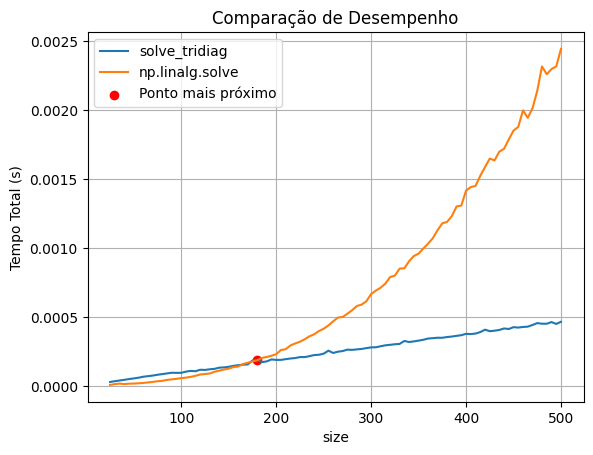

In [ ]:
df_comparativo = pd.DataFrame({
    "size": df_solve_tridiag["size"],
    "solve_tridiag": df_solve_tridiag["process_time"],
    "np.linalg.solve": df_linalg_solve["process_time"],
})

df_comparativo.plot(x="size", y=["solve_tridiag", "np.linalg.solve"], 
                    title="Comparação de Desempenho",
                    ylabel="Tempo Total (s)",
                    grid=True)

idx_mais_proximo = (df_comparativo["solve_tridiag"] - df_comparativo["np.linalg.solve"]).abs().idxmin()

x_cruzamento = df_comparativo.loc[idx_mais_proximo, "size"]
y_cruzamento = df_comparativo.loc[idx_mais_proximo, "np.linalg.solve"]


plt.scatter(x_cruzamento, y_cruzamento, color='red', label='Ponto mais próximo')
plt.legend()
plt.show()

In [67]:
print(x_cruzamento)

180
